<a href="https://colab.research.google.com/github/nithishavittam/-PRODIGY_WD_02-/blob/main/PRODIGY_WD_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

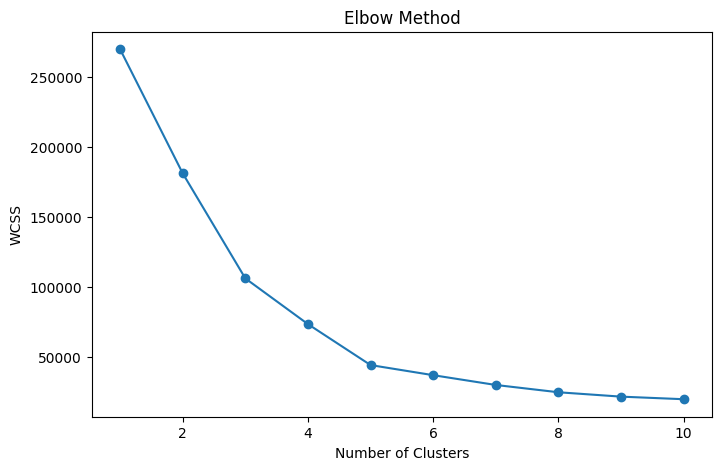

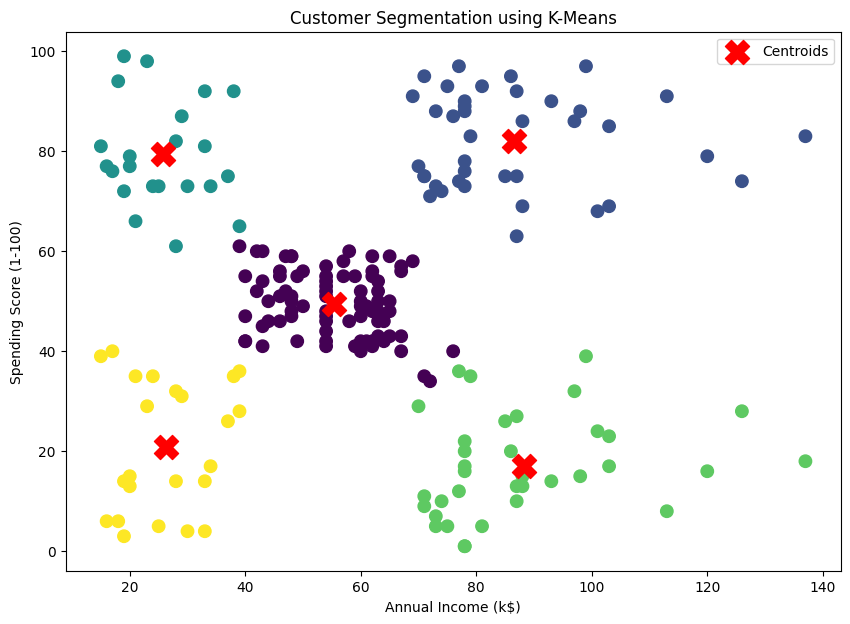

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64
Customer segmentation completed successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load Dataset
df = pd.read_csv('/content/Mall_Customers (1).csv')

# Select Features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Apply K-Means (Optimal Clusters = 5)
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

# Visualize Clusters
plt.figure(figsize=(10,7))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=df['Cluster'],
    cmap='viridis',
    s=80
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

# Display Cluster Counts
print(df['Cluster'].value_counts())

# Save Output
df.to_csv('customer_segments.csv', index=False)

print('Customer segmentation completed successfully!')